# EXPLORATORY DATA ANALYSIS

## Setup

In [15]:
# %matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import heapq
from pathlib import Path
sns.set(color_codes=True)

In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_FOLDER = PROJECT_ROOT / "data" / "processed"

games_df = pd.read_csv(DATA_FOLDER / "games.csv")
users_df = pd.read_csv(DATA_FOLDER / "users.csv")
recommendations_df = pd.read_csv(DATA_FOLDER / "recommendations.csv")
games_df = games_df.drop(columns=['price_final'])

## Verifying data correctness

In [3]:
# games_df.dtypes
games_df.count()
users_df.count()
recommendations_df.dtypes

app_id              int64
helpful             int64
funny               int64
date               object
is_recommended       bool
hours             float64
user_id             int64
review_id           int64
dtype: object

In [4]:
games_df.dtypes

app_id              int64
title              object
date_release       object
win                  bool
mac                  bool
linux                bool
rating             object
positive_ratio      int64
user_reviews        int64
price_original    float64
discount          float64
steam_deck           bool
rating_score      float64
dtype: object

In [5]:
users_df.dtypes

user_id     int64
products    int64
reviews     int64
dtype: object

## Outliers identification

<Axes: xlabel='rating_score'>

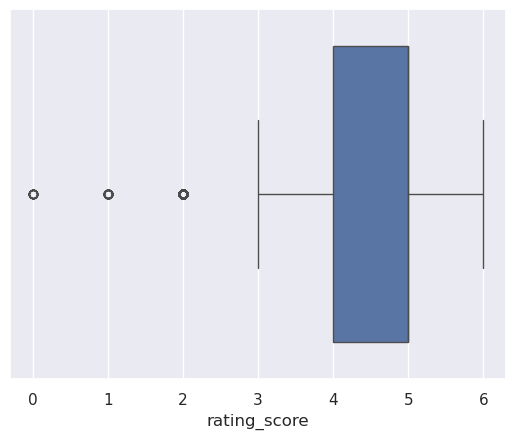

In [6]:
sns.boxplot(x=games_df.rating_score)

<Axes: xlabel='price_original'>

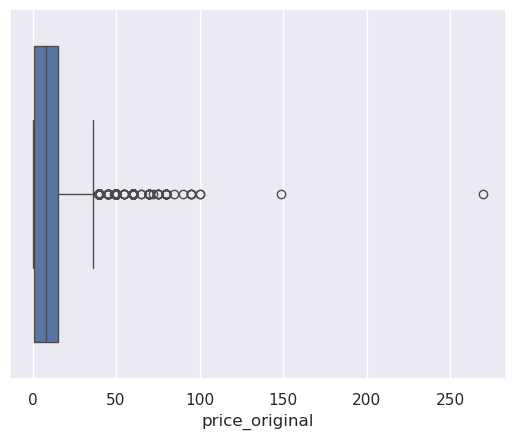

In [8]:
sns.boxplot(x=games_df.price_original)
# price >= 100 outliers?
# games_df = games_df[games_df['price_original'] < 100]

## Stats

## Top 20 Games by Playtime
Ranking the games by the playtime of the average user (using the ones who wrote a review).

In [21]:
grouped = recommendations_df.groupby('app_id')['hours'].mean()

d = grouped.to_dict()

top_20_items = heapq.nlargest(
    20,
    d.items(),
    key=lambda item: item[1]
)
top_20 = []
for key, value in top_20_items:
    top_20.append((key, value))

for i in range(20):
    v = games_df[games_df['app_id']==top_20[i][0]]
    print(f'{i+1}. "{v['title'].values[0]}", avg = {top_20[i][1]:.1f}')

1. "Counter-Strike: Global Offensive", avg = 440.3
2. "Dota 2", avg = 426.0
3. "YoloMouse", avg = 416.1
4. "Europa Universalis IV", avg = 397.5
5. "FINAL FANTASY XIV Online", avg = 374.9
6. "sheepChat", avg = 374.0
7. "Hearts of Iron IV", avg = 373.5
8. "MODO indie", avg = 372.9
9. "Wizard And Minion Idle", avg = 369.3
10. "OVR Advanced Settings", avg = 366.4
11. "Warframe", avg = 365.7
12. "Tom Clancy's Rainbow Six® Siege", avg = 362.0
13. "XSOverlay", avg = 361.0
14. "NGU IDLE", avg = 358.0
15. "Increlution", avg = 357.1
16. "Dead by Daylight", avg = 347.8
17. "Granado Espada", avg = 345.9
18. "Rust", avg = 345.4
19. "Total War: WARHAMMER II", avg = 338.1
20. "Destiny 2", avg = 337.4


## Correlation between avg hours played and positive ratio

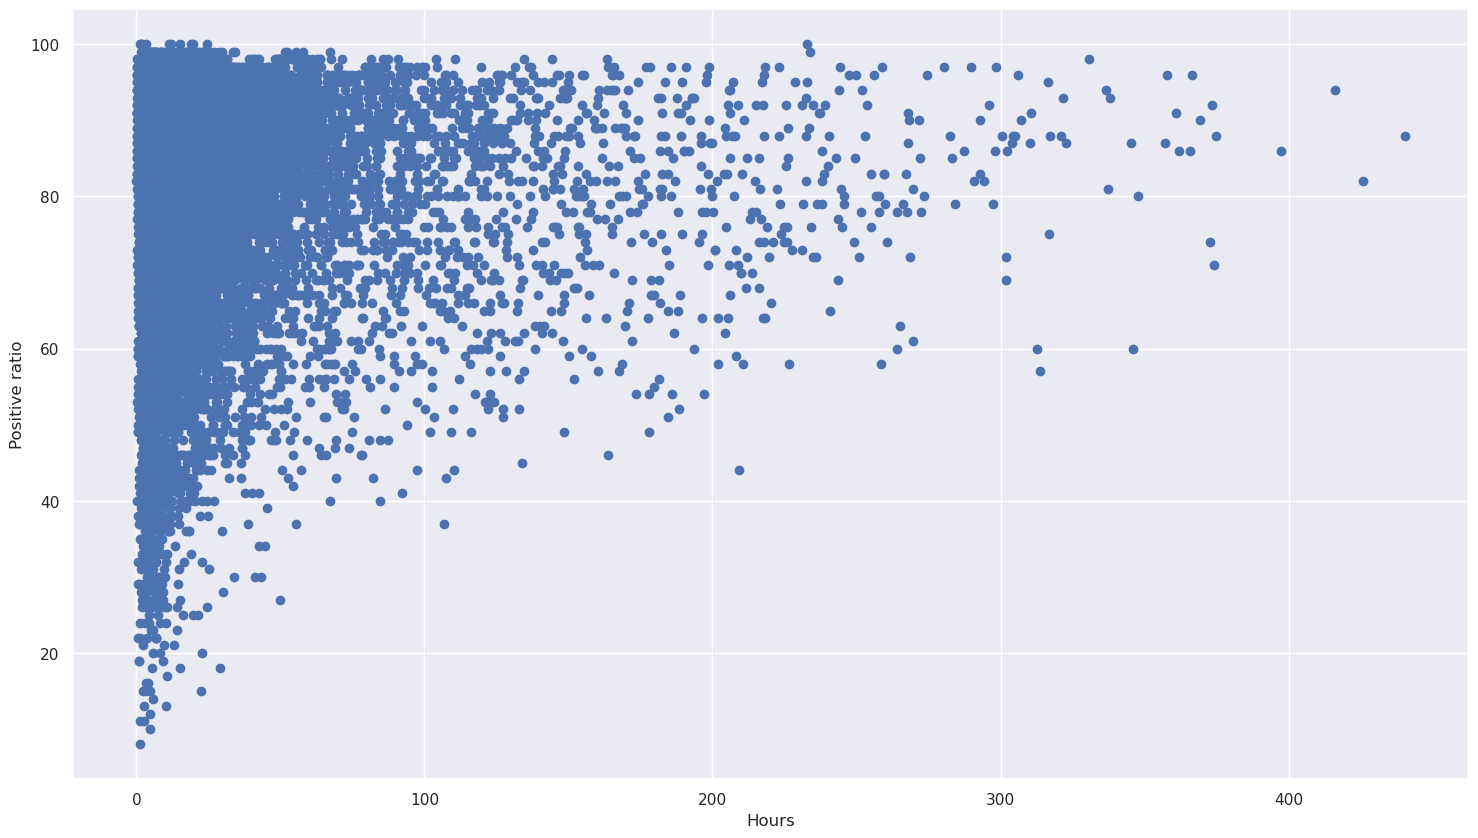

In [33]:
merged = pd.merge(games_df, grouped, on='app_id', how='inner')
fig, ax = plt.subplots(figsize=(18,10))
ax.scatter(merged['hours'], merged['positive_ratio'])
ax.set_xlabel('Hours')
ax.set_ylabel('Positive ratio')
plt.show()